<a href="https://colab.research.google.com/github/PriadiCuanda-231401058/Fundamental-Analisis-Data/blob/main/Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Bike Sharing Dataset (Hour.csv)
- **Nama:** Priadi Cuanda
- **Email:** priadicuanda2904@gmail.com
- **ID Dicoding:** CDCC319D6Y0576

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah total peminjaman sepeda (cnt) pada tahun 2012 jika dibandingkan dengan 2011?
- Pada jam berapa terjadi lonjakan peminjaman sepeda tertinggi pada hari kerja (workingday = 1) dibandingkan hari libur/akhir pekan (workingday = 0) pada tahun 2011 sampai dengan 2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
df = pd.read_csv("https://drive.google.com/uc?id=1NchZqbAKvUYXDUsPrhZASlM4M1uv-w7V")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Ukuran Data: Dataset yang berhasil dimuat (hour.csv) memiliki dimensi yang cukup besar, yaitu 17.379 baris observasi dan 17 kolom atribut. Ini menunjukkan data direkam secara detail setiap jamnya.

Karakteristik Atribut: Dataset ini sangat kaya akan fitur karena mencakup dimensi waktu (tanggal, musim, tahun, bulan, jam, hari libur/kerja), dimensi lingkungan/cuaca (suhu, kelembapan, kecepatan angin, kondisi cuaca), dan variabel target penyewaan (pengguna kasual, pengguna terdaftar, dan total penyewaan).

### Assessing Data

In [3]:
# 1. Memeriksa tipe data dan informasi umum
print("Info Dataset:")
df.info()

# 2. Memeriksa keberadaan missing values (nilai kosong)
print("\nJumlah Missing Values:")
print(df.isna().sum())

# 3. Memeriksa duplikasi data
print("\nJumlah Duplikasi: ", df.duplicated().sum())

# 4. Melihat ringkasan parameter statistik
display(df.describe())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah Missing Values:
instant    

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
Hasil Assessment:

Tidak ada missing values (semua kolom berjumlah 17.379 non-null).

Tidak ada data yang duplikat (0).

Terdapat ketidaksesuaian tipe data pada kolom dteday yang bertipe object (string), padahal seharusnya datetime.

Nilai pada kolom kategori (seperti musim dan cuaca) masih berupa angka, sehingga akan sulit dipahami saat divisualisasikan nanti.

### Cleaning Data

In [4]:
# 1. Mengubah tipe data 'dteday' menjadi datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# 2. Mengganti nama beberapa kolom agar lebih deskriptif
df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather_condition',
    'cnt': 'total_count'
}, inplace=True)

# 3. Melakukan mapping nilai angka menjadi teks deskriptif
# Mapping Musim (Season)
df['season'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Mapping Tahun (Year)
df['year'] = df['year'].map({0: '2011', 1: '2012'})

# Mapping Kondisi Cuaca (Weather Condition)
df['weather_condition'] = df['weather_condition'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
})

# 4. Mengecek hasil pembersihan data
print(df.head())

   instant       date  season  year  month  hour  holiday  weekday  \
0        1 2011-01-01  Spring  2011      1     0        0        6   
1        2 2011-01-01  Spring  2011      1     1        0        6   
2        3 2011-01-01  Spring  2011      1     2        0        6   
3        4 2011-01-01  Spring  2011      1     3        0        6   
4        5 2011-01-01  Spring  2011      1     4        0        6   

   workingday    weather_condition  temp   atemp   hum  windspeed  casual  \
0           0  Clear/Partly Cloudy  0.24  0.2879  0.81        0.0       3   
1           0  Clear/Partly Cloudy  0.22  0.2727  0.80        0.0       8   
2           0  Clear/Partly Cloudy  0.22  0.2727  0.80        0.0       5   
3           0  Clear/Partly Cloudy  0.24  0.2879  0.75        0.0       3   
4           0  Clear/Partly Cloudy  0.24  0.2879  0.75        0.0       0   

   registered  total_count  
0          13           16  
1          32           40  
2          27           32  


**Insight:**

Optimasi Deret Waktu: Pengubahan tipe data date menjadi datetime merupakan langkah krusial. Insight-nya, data sekarang sudah siap digunakan untuk analisis tren time-series atau jika kita ingin mengekstrak hari, minggu, atau periode waktu tertentu secara dinamis.

Keterbacaan Data: Transformasi (mapping) angka menjadi teks pada kolom kategorikal (seperti season, year, dan weather_condition) serta penggantian nama kolom membuat dataset menjadi human-readable. Insight utamanya adalah dataset kini siap untuk divisualisasikan; kita tidak perlu lagi menebak bahwa "cuaca 1" berarti "cerah", sehingga mencegah misinterpretasi saat mempresentasikan dashboard nanti.

## Exploratory Data Analysis (EDA)

### Explore Bike Sharing Dataset 2011-2012


Sampel Data:


,instant,date,season,year,month,hour,holiday,weekday,workingday,weather_condition,temp,atemp,hum,windspeed,casual,registered,total_count
13051,13052,2012-07-03,Fall,2012,7,0,0,2,1,Clear/Partly Cloudy,0.72,0.6667,0.54,0.0000,9,44,53
10771,10772,2012-03-29,Summer,2012,3,22,0,4,1,Clear/Partly Cloudy,0.42,0.4242,0.44,0.2836,17,135,152
16977,16978,2012-12-15,Winter,2012,12,4,0,6,0,Mist/Cloudy,0.24,0.2576,0.87,0.1045,1,5,6
5413,5414,2011-08-18,Fall,2011,8,11,0,4,1,Clear/Partly Cloudy,0.76,0.7121,0.58,0.2537,44,97,141
15505,15506,2012-10-13,Winter,2012,10,6,0,6,0,Clear/Partly Cloudy,0.30,0.2879,0.61,0.1940,5,23,28



Rangkuman Parameter Statistik:


,instant,date,season,year,month,hour,holiday,weekday,workingday,weather_condition,temp,atemp,hum,windspeed,casual,registered,total_count
count,17379.0000,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,NaN,NaN,NaN,NaN,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


--- 1. Eksplorasi Distribusi Banyak Fitur ---


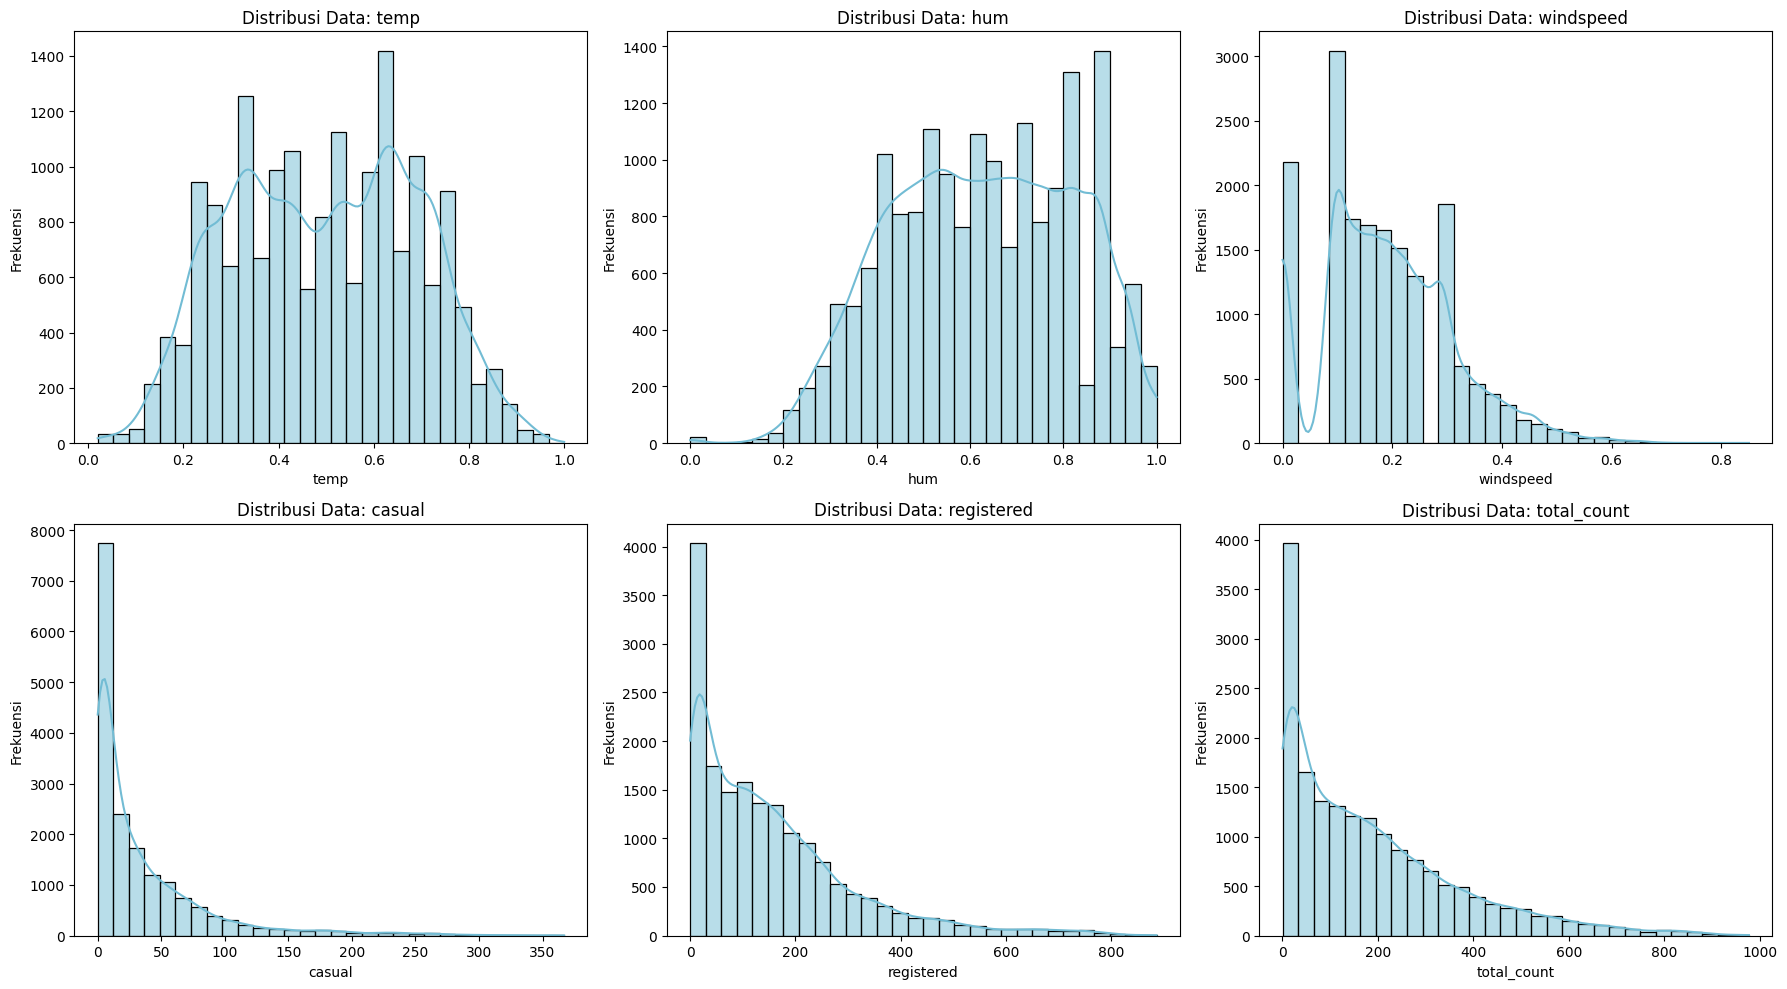


--- 2. Eksplorasi Matriks Korelasi (Lebih Detail) ---


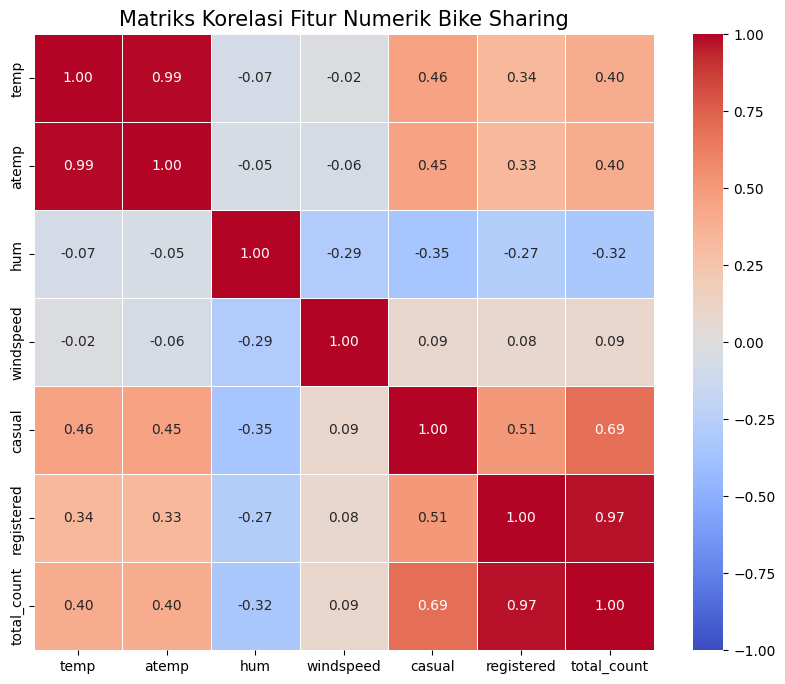

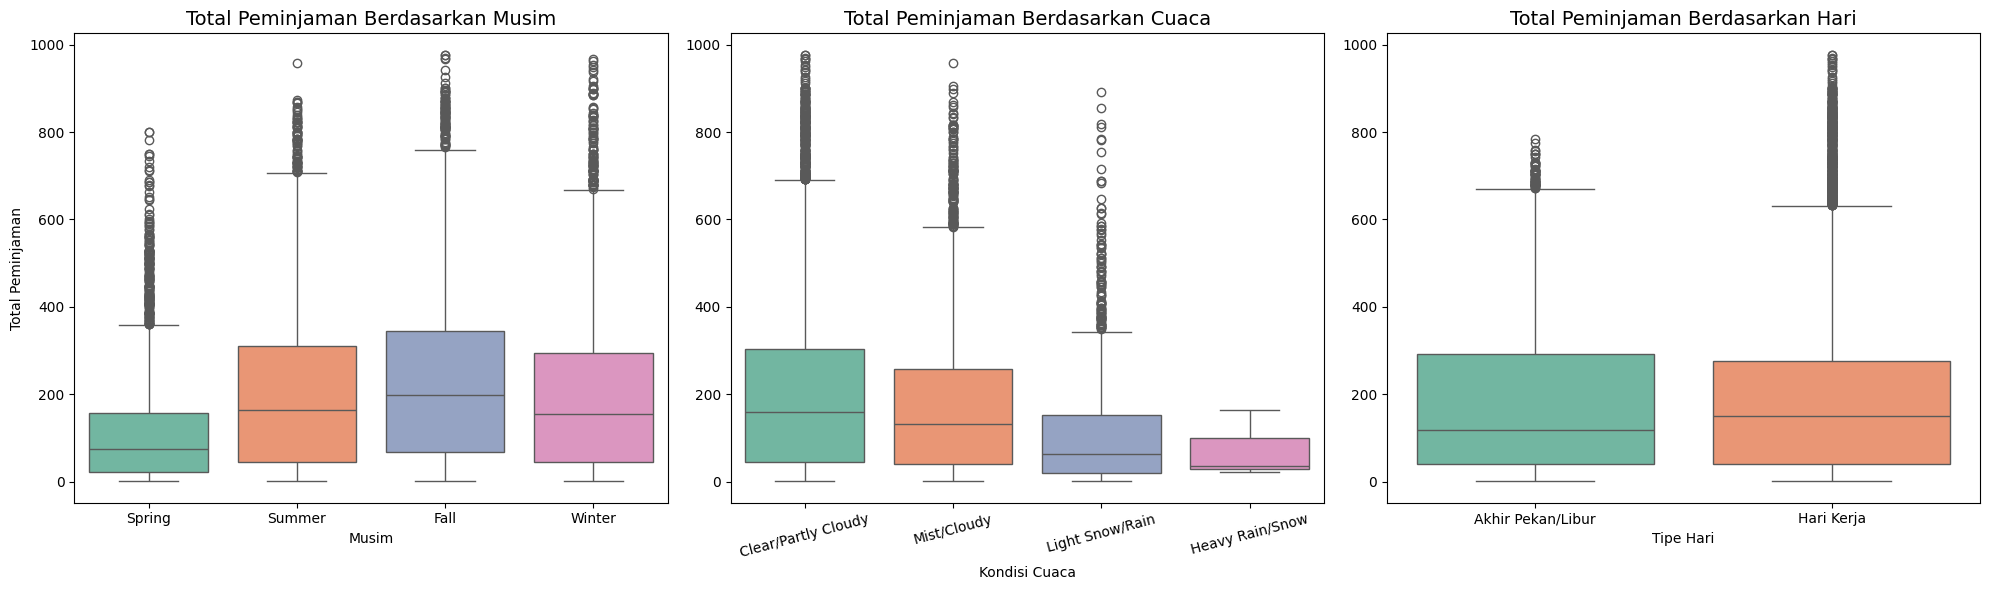


Agregasi Berdasarkan Tahun dan Kondisi Cuaca:


total_count                     
                                 sum  max min        mean
year weather_condition                                   
2011 Clear/Partly Cloudy      875053  651   1  155.013818
     Heavy Rain/Snow              36   36  36   36.000000
     Light Snow/Rain           67495  579   1   86.421255
     Mist/Cloudy              300519  604   1  135.490983
2012 Clear/Partly Cloudy     1463120  977   1  253.661581
     Heavy Rain/Snow             187  164  23   93.500000
     Light Snow/Rain           90836  891   1  142.376176
     Mist/Cloudy              495433  957   1  212.997850


Top 5 Jam Peminjaman Tertinggi di Hari Kerja (workingday=1):


workingday hour total_count                 
                          mean  max min     sum
41          1   17  525.290581  976  26  262120
42          1   18  492.226908  977  26  245129
32          1    8  477.006048  839  31  236595
43          1   19  348.401606  743  18  173504
40          1   16  293.122244  634  13  146268


Top 5 Jam Peminjaman Tertinggi di Hari Libur (workingday=0):


workingday hour total_count                
                          mean  max min    sum
13          0   13  372.731602  760  30  86101
12          0   12  366.259740  776  32  84606
14          0   14  364.645022  750  23  84233
15          0   15  358.813853  750   7  82886
16          0   16  352.727273  783  11  81480


Agregasi Berdasarkan Musim:


total_count                     
               sum        mean  max min
season                                 
Fall       1061129  236.016237  977   1
Summer      918589  208.344069  957   1
Winter      841613  198.868856  967   1
Spring      471348  111.114569  801   1

                                 total_count        
                                        mean     sum
workingday time_of_day                              
0          Malam (21:00 - 04:59)   74.155568  135853
           Pagi (05:00 - 11:59)   132.161893  212252
           Siang (12:00 - 16:59)  363.035498  419306
           Sore (17:00 - 20:59)   252.831705  232858
1          Malam (21:00 - 04:59)   61.721555  241393
           Pagi (05:00 - 11:59)   204.358398  709328
           Siang (12:00 - 16:59)  215.492369  536576
           Sore (17:00 - 20:59)   403.970396  805113


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Menampilkan sampel data awal
print("Sampel Data:")
display(df.sample(5))

# Eksplorasi Parameter Statistik
print("\nRangkuman Parameter Statistik:")
display(df.describe(include="all"))

# Visualisasi Distribusi Data (Target: total_count)
print("--- 1. Eksplorasi Distribusi Banyak Fitur ---")
# Kita akan melihat distribusi untuk Suhu, Kelembapan, Kecepatan Angin, Pengguna Kasual, Pengguna Terdaftar, dan Total
features_to_plot = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'total_count']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="#72BCD4")
    axes[i].set_title(f"Distribusi Data: {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

print("\n--- 2. Eksplorasi Matriks Korelasi (Lebih Detail) ---")
# Mengambil kolom numerik saja
numeric_columns = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'total_count']
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Matriks Korelasi Fitur Numerik Bike Sharing", fontsize=15)
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# Hubungan Musim (Categorical) dengan Total Peminjaman (Numeric)
sns.boxplot(x="season", y="total_count", hue="season", data=df, ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Total Peminjaman Berdasarkan Musim", fontsize=14)
axes[0].set_xlabel("Musim")
axes[0].set_ylabel("Total Peminjaman")

# Hubungan Kondisi Cuaca (Categorical) dengan Total Peminjaman (Numeric)
sns.boxplot(x="weather_condition", y="total_count", hue="weather_condition", data=df, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Total Peminjaman Berdasarkan Cuaca", fontsize=14)
axes[1].set_xlabel("Kondisi Cuaca")
axes[1].set_ylabel("") # Kosongkan agar rapi
axes[1].tick_params(axis='x', rotation=15)

# Hubungan Hari Kerja (Categorical Binary) dengan Total Peminjaman (Numeric)
df_temp = df.copy()
df_temp['workingday'] = df_temp['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})

sns.boxplot(x="workingday", y="total_count", hue="workingday", data=df_temp, ax=axes[2], palette="Set2", legend=False)
axes[2].set_title("Total Peminjaman Berdasarkan Hari", fontsize=14)
axes[2].set_xlabel("Tipe Hari")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

# Eksplorasi Agregasi: Menjawab Pertanyaan Bisnis 1 (Cuaca & Tahun)
print("\nAgregasi Berdasarkan Tahun dan Kondisi Cuaca:")
weather_agg = df.groupby(by=["year", "weather_condition"]).agg({
    "total_count": ["sum", "max", "min", "mean"]
})
display(weather_agg)

# Eksplorasi Agregasi: Menjawab Pertanyaan Bisnis 2 (Tren Waktu & Hari Kerja)
hour_summary = df.groupby(by=["workingday", "hour"]).agg({
    "total_count": ["mean", "max", "min", "sum"]
}).reset_index()

print("\nTop 5 Jam Peminjaman Tertinggi di Hari Kerja (workingday=1):")
display(hour_summary[hour_summary['workingday'] == 1].sort_values(by=("total_count", "mean"), ascending=False).head())

print("\nTop 5 Jam Peminjaman Tertinggi di Hari Libur (workingday=0):")
display(hour_summary[hour_summary['workingday'] == 0].sort_values(by=("total_count", "mean"), ascending=False).head())

# Eksplorasi Tambahan: Agregasi Tren Musim (Seasonality)
print("\nAgregasi Berdasarkan Musim:")
season_agg = df.groupby(by="season").agg({
    "total_count": ["sum", "mean", "max", "min"]
}).sort_values(by=("total_count", "sum"), ascending=False)
display(season_agg)


def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hour < 17:
        return 'Siang (12:00 - 16:59)'
    elif 17 <= hour < 21:
        return 'Sore (17:00 - 20:59)'
    else:
        return 'Malam (21:00 - 04:59)'

# Menerapkan fungsi ke dalam kolom baru 'time_of_day'
df['time_of_day'] = df['hour'].apply(get_time_of_day)

# Pivot table berdasarkan segmentasi waktu dan hari
time_cluster_summary = df.groupby(by=["workingday", "time_of_day"]).agg({
    "total_count": ["mean", "sum"]
})
print(time_cluster_summary)

df.to_csv("cleaned_hour.csv", index=False)

**Insight:**

1. Eksplorasi Rangkuman Parameter Statistik
- Secara rata-rata dalam satu jam, total sepeda yang dipinjam (total_count) adalah sekitar 189 sepeda.
- Nilai maksimum peminjaman dalam satu jam pernah mencapai 977 sepeda.
- Peminjaman didominasi oleh registered user (rata-rata 153 penyewaan/jam) dibandingkan casual user (rata-rata 35 penyewaan/jam).

2. Distribusi Data:
- Dari 6 grafik histogram yang dihasilkan, kita mendapatkan informasi mengenai persebaran metrik lingkungan dan perilaku pengguna:

    - temp (Suhu): Memiliki distribusi yang cukup normal (menyerupai lonceng) namun sedikit mendatar di tengah. Ini mencerminkan siklus musim, di mana hari-hari bersuhu sedang lebih sering muncul dibandingkan suhu sangat ekstrem (terlalu dingin atau terlalu panas).

    - hum (Kelembapan): Distribusinya sedikit left-skewed (miring ke kiri), artinya kondisi cuaca di lokasi persewaan lebih sering berada pada tingkat kelembapan menengah hingga tinggi (di atas 0.4 atau 40%).

    - windspeed (Kecepatan Angin): Memiliki kemiringan positif (right-skewed). Mayoritas kecepatan angin bernilai rendah hingga sedang. Data ini sangat wajar karena badai atau angin kencang adalah anomali yang jarang terjadi.

    - casual, registered, dan total_count (Tipe Pengguna): Ketiga fitur ini memiliki distribusi right-skewed yang sangat tajam. Mayoritas frekuensi harian/jam menunjukkan jumlah peminjaman di rentang rendah-menengah. Grafik registered jauh lebih lebar menyebar dibandingkan casual, menegaskan bahwa inti (tulang punggung) bisnis ini didorong oleh pelanggan tetap (registered users).

- Suhu (temp) vs Total Peminjaman (total_count): Korelasi 0.40
Terdapat korelasi positif yang cukup baik. Artinya, secara umum, suhu yang lebih hangat akan mendorong lebih banyak orang untuk menyewa sepeda.

- Suhu dan Pengguna Kasual (temp vs casual): Korelasi 0.46
Insight tersembunyi yang sangat menarik! Jika dibandingkan, korelasi suhu dengan pelanggan kasual (0.46) jauh lebih kuat dibandingkan korelasi suhu dengan pelanggan terdaftar/registered (0.34). Ini berarti pengguna kasual sangat sensitif terhadap cuaca/suhu. Mereka hanya ingin bersepeda saat cuaca hangat/nyaman (untuk rekreasi). Sebaliknya, pengguna terdaftar akan tetap meminjam sepeda meskipun suhu sedikit kurang bersahabat (karena untuk mobilitas kerja/rutin).

- Kelembapan (hum) vs Peminjaman: Korelasi -0.32
Hubungan berbanding terbalik. Semakin lembap udara (biasanya identik dengan mendung, kabut, atau akan hujan), keinginan orang untuk bersepeda menjadi turun.

- Kecepatan Angin (windspeed) vs Peminjaman: Korelasi 0.09
Sangat mengejutkan, korelasi kecepatan angin nyaris mendekati nol. Artinya, dalam skala data harian/jam secara umum, tingkat kecepatan angin (selama bukan badai) tidak memberikan pengaruh yang berarti terhadap keputusan orang menyewa sepeda.

- Multikolinearitas temp dan atemp: Korelasi 0.99
Kedua fitur ini nyaris berkorelasi sempurna (0.99). temp adalah suhu aktual dan atemp adalah suhu yang dirasakan (feels like). Karena informasi keduanya pada dasarnya sama, untuk pemodelan machine learning ke depannya (meski tidak dipakai di modul ini), salah satu fitur ini lebih baik didrop (dibuang) untuk menghindari multikolinearitas (informasi ganda yang membingungkan).

- Musim vs Total Peminjaman: Boxplot menunjukkan bahwa kotak untuk Musim Gugur (Fall) dan Musim Panas (Summer) posisinya lebih tinggi dibandingkan musim lainnya. Median (garis di tengah kotak) pada musim gugur adalah yang tertinggi. Di sisi lain, Musim Semi (Spring) memiliki median dan batas bawah/atas yang paling rendah. Ini mengonfirmasi bahwa musim memiliki pengaruh kuat terhadap variansi jumlah peminjaman.

- Cuaca vs Total Peminjaman: Bentuk kotak pada cuaca Clear/Partly Cloudy (Cerah) sangat lebar ke atas, menandakan distribusi peminjaman yang tinggi banyak terjadi di cuaca ini. Sebaliknya, pada cuaca Heavy Rain/Snow (Hujan/Salju Lebat), kotaknya sangat pipih dan berada di bawah (hampir menyentuh angka 0). Ini menunjukkan hubungan yang sangat kuat: cuaca buruk hampir pasti mematikan tingkat peminjaman.

- Hari Kerja vs Akhir Pekan:
Meskipun secara rata-rata harian peminjaman di Hari Kerja dan Akhir Pekan terlihat mirip, titik-titik outlier (titik hitam di atas kotak) lebih banyak dan padat terjadi pada Hari Kerja. Ini terjadi karena lonjakan ekstrem pada jam masuk dan pulang kerja, yang menyebabkan angka jam-jaman tertentu menembus batas distribusi normalnya dibandingkan hari libur yang polanya lebih landai.

3. Korelasi Data: Matriks korelasi memperlihatkan hubungan positif yang cukup moderat antara variabel suhu (temp dan atemp) dengan total_count (korelasi ~0.40). Hal ini berarti ketika suhu semakin hangat, minat menyewa sepeda cenderung meningkat. Di sisi lain, variabel kelembapan (hum) memiliki korelasi negatif (-0.32), menandakan tingkat kelembapan yang tinggi menurunkan jumlah penyewaan.

4. Eksplorasi Hubungan Cuaca terhadap Jumlah Peminjaman (Menjawab Pertanyaan Bisnis 1)
- Cuaca Cerah (Clear/Partly Cloudy) menghasilkan rata-rata peminjaman tertinggi secara konsisten. Di tahun 2012, rata-ratanya mencapai 253 sepeda/jam, naik drastis dibandingkan tahun 2011 (155 sepeda/jam).
- Ketika cuaca memburuk (Light Snow/Rain atau Heavy Rain), tingkat peminjaman jatuh secara signifikan. Bahkan, cuaca Heavy Rain pada tahun 2011 hanya mencatatkan 36 total penyewaan, sangat sepi.


5. Eksplorasi Pola Peminjaman Berdasarkan Waktu dan Hari Kerja (Menjawab Pertanyaan Bisnis 2)
- Di Hari Kerja (workingday = 1): Puncak peminjaman terjadi pada Jam 17:00 (525 sepeda) dan Jam 18:00 (492 sepeda), diikuti oleh lonjakan di pagi hari pada Jam 08:00 (477 sepeda). Pola ini sangat mencerminkan waktu berangkat dan pulang kerja/sekolah.
- Di Akhir Pekan/Libur (workingday = 0): Polanya sama sekali berbeda. Puncaknya bergeser ke tengah hari, mulai dari Jam 12:00 hingga Jam 16:00, di mana masing-masing jam rata-rata mencatatkan 350-370 penyewaan. Ini mencerminkan kegiatan rekreasi.


6. Advanced Analysis: Clustering / Binning Waktu Secara Manual
- Hasil binning memperkuat temuan sebelumnya: Jika di hari kerja, klaster Sore (rata-rata 403 sepeda) dan Pagi (rata-rata 204 sepeda) sangat mendominasi.
- Jika di akhir pekan, pelanggan paling aktif meminjam pada klaster Siang (rata-rata 363 sepeda).
- Klaster Malam adalah waktu yang paling tidak produktif, baik di hari kerja maupun hari libur (rata-rata hanya 61-74 sepeda).


## Visualization & Explanatory Analysis

### Pertanyaan 1:

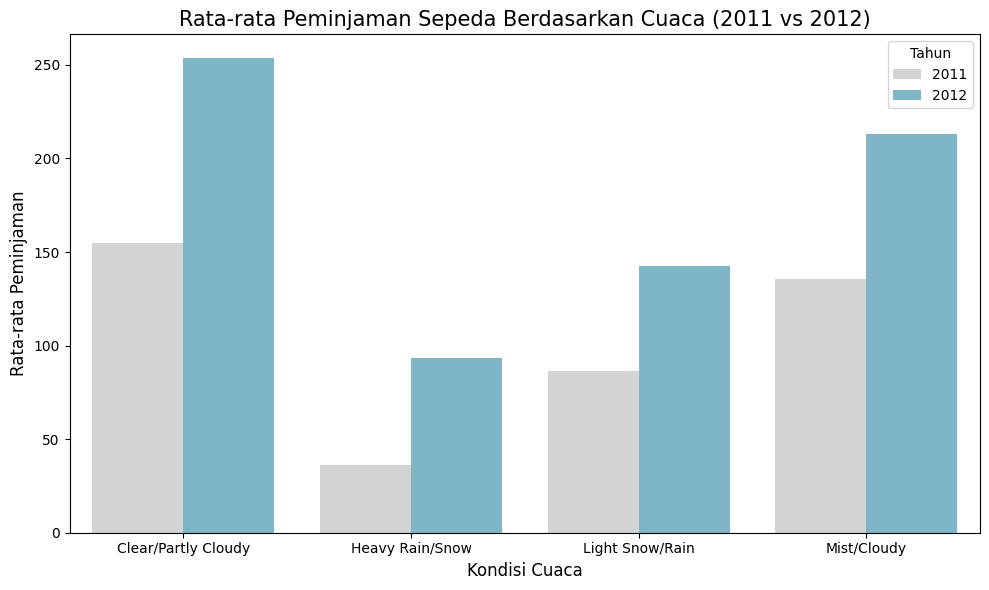

In [6]:
df['date'] = pd.to_datetime(df['date'])

# Visualisasi 1: Pertanyaan 1 - Pengaruh Cuaca dan Tahun terhadap Total Peminjaman
weather_summary = df.groupby(by=["year", "weather_condition"]).agg({
    "total_count": "mean"
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x="weather_condition",
    y="total_count",
    hue="year",
    data=weather_summary,
    palette=["#D3D3D3", "#72BCD4"]
)
plt.title("Rata-rata Peminjaman Sepeda Berdasarkan Cuaca (2011 vs 2012)", fontsize=15)
plt.ylabel("Rata-rata Peminjaman", fontsize=12)
plt.xlabel("Kondisi Cuaca", fontsize=12)
plt.legend(title="Tahun")
plt.tight_layout()
plt.show()

### Pertanyaan 2:

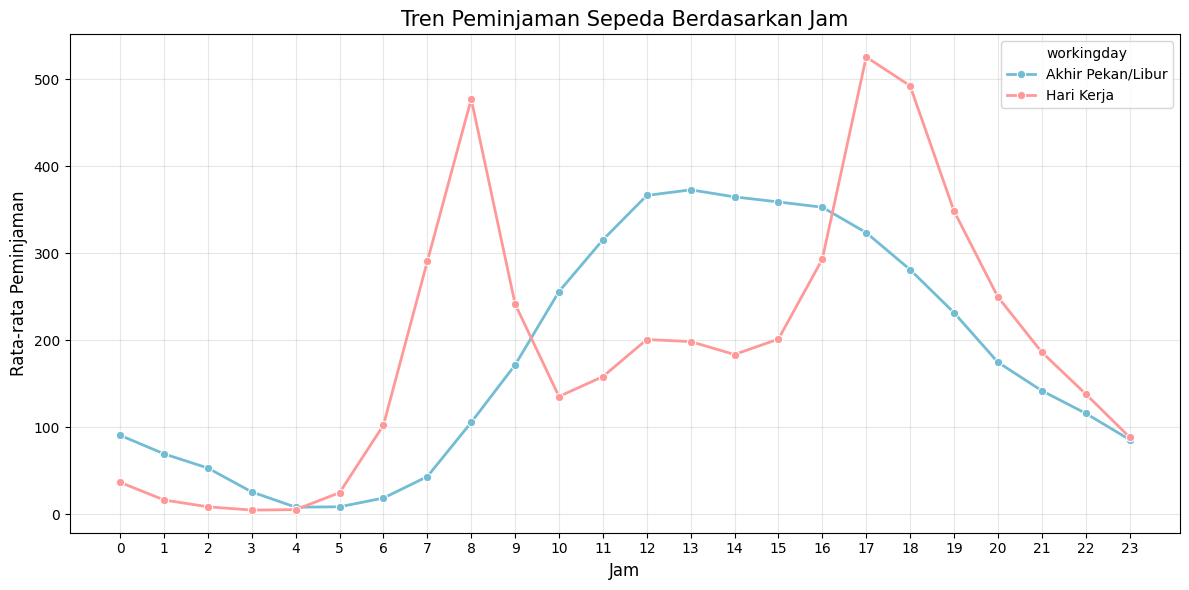

In [7]:
# Visualisasi 2: Pertanyaan 2 - Tren Peminjaman Berdasarkan Jam (Hari Kerja vs Libur)
hour_summary = df.groupby(by=["workingday", "hour"]).agg({
    "total_count": "mean"
}).reset_index()

hour_summary['workingday'] = hour_summary['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})

plt.figure(figsize=(12, 6))
sns.lineplot(
    x="hour",
    y="total_count",
    hue="workingday",
    data=hour_summary,
    marker="o",
    linewidth=2,
    palette=["#72BCD4", "#FF9999"]
)
plt.title("Tren Peminjaman Sepeda Berdasarkan Jam", fontsize=15)
plt.ylabel("Rata-rata Peminjaman", fontsize=12)
plt.xlabel("Jam", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**

1. Insight dari Bar Chart: Rata-rata Peminjaman Sepeda Berdasarkan Cuaca
- Preferensi Cuaca: Pengguna sangat sensitif terhadap kondisi cuaca. Cuaca Cerah / Berawan Sebagian (Clear/Partly Cloudy) adalah kondisi yang paling ideal dan mencatatkan rata-rata peminjaman tertinggi.

- Penurunan Drastis pada Cuaca Buruk: Semakin buruk kondisi cuaca (seperti Hujan Lebat atau Salju), minat menyewa sepeda langsung anjlok secara drastis hingga menyentuh angka terendah. Ini menunjukkan bahwa layanan ini sangat bergantung pada faktor alam.

- Pertumbuhan Bisnis: Jika membandingkan warna batang tahun 2011 dan 2012, terlihat jelas bahwa pada setiap kondisi cuaca, penyewaan di tahun 2012 selalu jauh lebih tinggi daripada tahun 2011. Hal ini membuktikan adanya pertumbuhan bisnis (skalabilitas) dan tren adopsi pengguna yang sangat positif dari tahun ke tahun.

2. Insight dari Line Chart: Tren Peminjaman Sepeda Berdasarkan Jam
- Pola Komuter di Hari Kerja (Bimodal): Pada hari kerja, grafik membentuk dua puncak tajam (bimodal distribution), yaitu pada pukul 08:00 pagi dan pukul 17:00 - 18:00 sore. Insight utamanya adalah mayoritas pengguna di hari kerja meminjam sepeda untuk keperluan mobilitas atau transportasi utama (berangkat dan pulang kerja/sekolah).

- Pola Rekreasi di Akhir Pekan/Libur (Unimodal): Pada hari libur, grafik membentuk satu puncak landai yang menyerupai bukit (unimodal distribution). Peminjaman mulai naik pada siang hari dan stabil di puncaknya pada rentang pukul 12:00 hingga 16:00 sore. Ini menandakan bahwa di hari libur, pelanggan menyewa sepeda untuk bersantai, berolahraga, atau rekreasi keliling kota.

- Jam Mati (Titik Terendah): Baik di hari kerja maupun hari libur, rentang waktu pukul 00:00 hingga 05:00 pagi adalah waktu dengan tingkat peminjaman terendah (hampir mendekati nol). Waktu ini sangat optimal jika perusahaan ingin melakukan perawatan (maintenance) atau distribusi ulang sepeda antar stasiun.

## Analisis Lanjutan (Opsional)

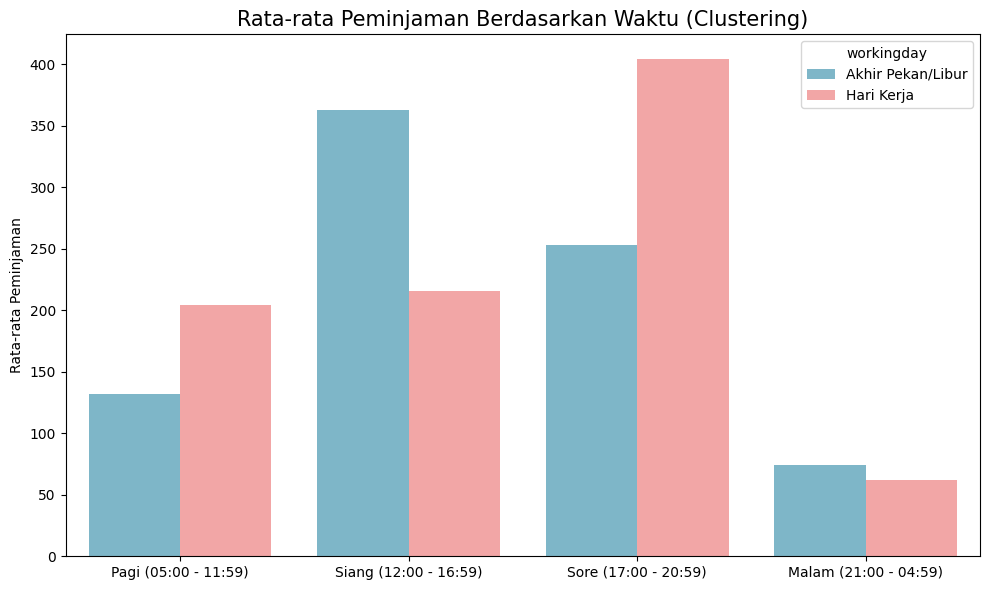

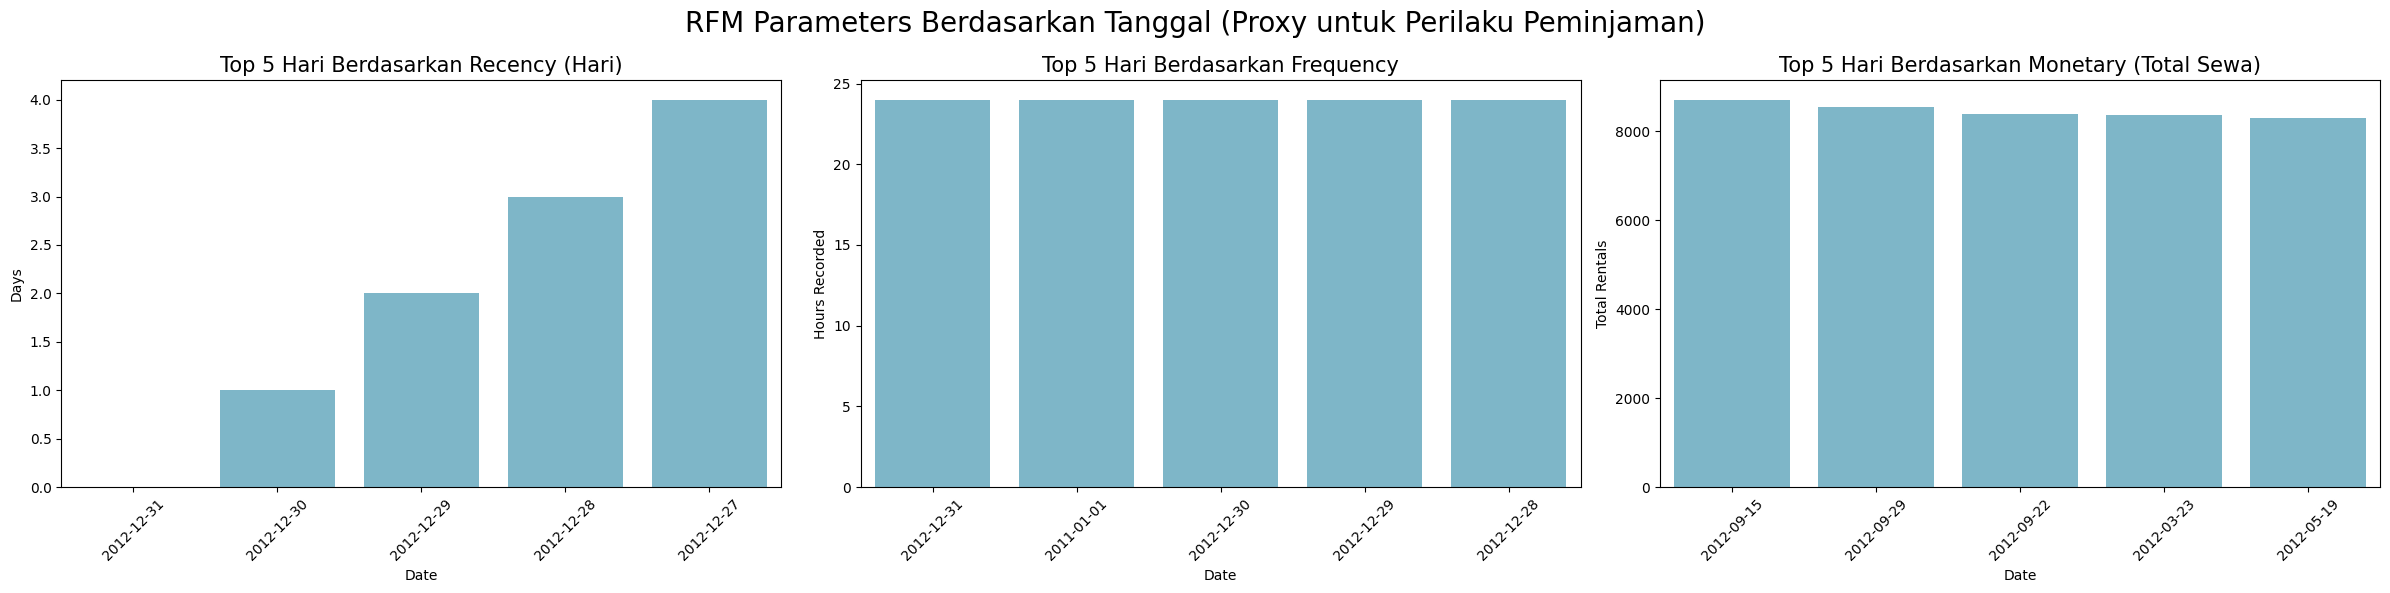

In [8]:
# Advanced Analysis: Clustering (Binning) Waktu
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hour < 17:
        return 'Siang (12:00 - 16:59)'
    elif 17 <= hour < 21:
        return 'Sore (17:00 - 20:59)'
    else:
        return 'Malam (21:00 - 04:59)'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

time_cluster_summary = df.groupby(by=["workingday", "time_of_day"]).agg({
    "total_count": "mean"
}).reset_index()
time_cluster_summary['workingday'] = time_cluster_summary['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})
time_cluster_summary['time_of_day'] = pd.Categorical(time_cluster_summary['time_of_day'], categories=['Pagi (05:00 - 11:59)', 'Siang (12:00 - 16:59)', 'Sore (17:00 - 20:59)', 'Malam (21:00 - 04:59)'], ordered=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="time_of_day",
    y="total_count",
    hue="workingday",
    data=time_cluster_summary,
    palette=["#72BCD4", "#FF9999"]
)
plt.title("Rata-rata Peminjaman Berdasarkan Waktu (Clustering)", fontsize=15)
plt.ylabel("Rata-rata Peminjaman")
plt.xlabel(None)
plt.tight_layout()
plt.show()

rfm_df = df.groupby('date').agg({
    'date': 'max',          # Proksi untuk Recency
    'instant': 'count',     # Frequency: Jumlah jam observasi yang terekam per hari
    'total_count': 'sum'    # Monetary: Total sepeda yang disewa per hari
}).rename(columns={'date': 'max_date', 'instant': 'frequency', 'total_count': 'monetary'})

# Menghitung Recency (selisih hari terakhir di dataset dengan tanggal observasi)
rfm_df['max_date'] = rfm_df['max_date'].dt.date
recent_date = df['date'].dt.date.max()
rfm_df['recency'] = rfm_df['max_date'].apply(lambda x: (recent_date - x).days)

# Merapikan tabel
rfm_df.drop('max_date', axis=1, inplace=True)
rfm_df.reset_index(inplace=True)

# Membuat kolom tanggal dalam bentuk string murni untuk keperluan visualisasi
rfm_df['date_str'] = rfm_df['date'].dt.strftime('%Y-%m-%d')
# Format the dates for display
rfm_df['date_str'] = rfm_df['date'].dt.strftime('%Y-%m-%d')

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))
colors = ["#72BCD4"] * 5

# Recency (Most recent 5 days)
sns.barplot(y="recency", x="date_str", hue="date_str", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0], legend=False)
ax[0].set_title("Top 5 Hari Berdasarkan Recency (Hari)", fontsize=15)
ax[0].set_ylabel("Days")
ax[0].set_xlabel("Date")
ax[0].tick_params(axis='x', rotation=45)

# Frequency (Days with most hours recorded)
sns.barplot(y="frequency", x="date_str", hue="date_str", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1], legend=False)
ax[1].set_title("Top 5 Hari Berdasarkan Frequency", fontsize=15)
ax[1].set_ylabel("Hours Recorded")
ax[1].set_xlabel("Date")
ax[1].tick_params(axis='x', rotation=45)

# Monetary (Days with highest total rentals)
sns.barplot(y="monetary", x="date_str", hue="date_str", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2], legend=False)
ax[2].set_title("Top 5 Hari Berdasarkan Monetary (Total Sewa)", fontsize=15)
ax[2].set_ylabel("Total Rentals")
ax[2].set_xlabel("Date")
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("RFM Parameters Berdasarkan Tanggal (Proxy untuk Perilaku Peminjaman)", fontsize=20)
plt.tight_layout()
plt.show()

## Conclusion

**Pertanyaan Bisnis 1: Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah total peminjaman sepeda (cnt) pada tahun 2012 dibandingkan 2011?**

Explanatory Analysis:

Cuaca memiliki pengaruh yang sangat signifikan terhadap perilaku pengguna. Kondisi Clear/Partly Cloudy (Cerah) adalah kondisi paling ideal yang menghasilkan rata-rata peminjaman tertinggi (mencapai lebih dari 250 sepeda per jam di tahun 2012). Sebaliknya, ketika cuaca Heavy Rain/Snow (Hujan Lebat/Salju), rata-rata peminjaman anjlok drastis ke angka di bawah 100.

Insight Tambahan: Terdapat pertumbuhan bisnis yang pesat dari tahun 2011 ke 2012, dibuktikan dengan batang biru yang selalu lebih tinggi dari batang abu-abu di semua kondisi cuaca.


**Pertanyaan Bisnis 2: Pada jam berapa terjadi lonjakan peminjaman sepeda tertinggi pada hari kerja dibandingkan hari libur/akhir pekan?**

Explanatory Analysis:

Pada hari kerja, terjadi dua lonjakan ekstrem (puncak) yang membentuk pola bimodal. Puncak pertama terjadi pada Jam 08:00 pagi dan puncak tertinggi terjadi pada Jam 17:00 hingga 18:00 sore. Ini mengindikasikan bahwa sepeda mayoritas digunakan oleh komuter untuk pergi dan pulang kantor/sekolah.

Sebaliknya, pada akhir pekan (garis merah muda), polanya menyerupai bukit tunggal. Peminjaman mulai naik perlahan sejak pagi dan stabil di puncaknya pada tengah hari hingga sore (12:00 - 16:00), yang mengindikasikan penggunaan untuk rekreasi atau olahraga.


**Explanatory Clustering (Binning) Waktu Secara Manual:**

Dari visualisasi ini, pesannya menjadi jauh lebih sederhana untuk ditangkap oleh audiens bisnis. Di hari kerja (Biru), Sore hari adalah segmen paling krusial. Namun, jika ini adalah hari libur (Merah Muda), operasional harus difokuskan pada pemeliharaan stok sepeda di rentang waktu Siang.

**Berdasarkan data:**

Kita perlu memastikan kondisi sepeda selalu prima dan tersedia dalam jumlah banyak menjelang pukul 08:00 pagi dan 17:00 sore di setiap hari kerja.

Promosi dan marketing campaign sebaiknya digencarkan saat cuaca cerah di akhir pekan (antara pukul 12:00 - 16:00) untuk menarik lebih banyak casual user.